In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler
from imblearn.over_sampling import SMOTE

import warnings
warnings.filterwarnings("ignore")


class PureSMOTE:

    def __init__(
        self,
        k_neighbors=5,
        random_state=42,
        verbose=True
    ):

        self.k_neighbors = k_neighbors
        self.random_state = random_state
        self.verbose = verbose

    def fit_resample(self, df, label_col="label_3"):
        np.random.seed(self.random_state)

        id_cols = ["user_id", "course_id"]
        feature_cols = [c for c in df.columns if c not in id_cols + [label_col]]

        # Scaling
        scaler = StandardScaler()
        X_scaled = scaler.fit_transform(df[feature_cols].values)
        y = df[label_col].values

        if self.verbose:
            print("\nSMOTE:")
            print("\nClass distribution BEFORE:")
            print(pd.Series(y).value_counts().sort_index())

        # SMOTE
        smoter = SMOTE(
            sampling_strategy='not majority',
            k_neighbors=self.k_neighbors,
            random_state=self.random_state
        )
        X_resampled, y_resampled = smoter.fit_resample(X_scaled, y)

        # Inverse transform
        X_original = scaler.inverse_transform(X_resampled)

        # Tạo DataFrame kết quả ban đầu
        df_final = pd.DataFrame(X_original, columns=feature_cols)
        df_final[label_col] = y_resampled

        original_size = len(df)
        n_new = len(df_final) - original_size

        if n_new > 0:
            synthetic_labels = y_resampled[original_size:]
            syn_ids = {col: [] for col in id_cols if col in df.columns}
            
            # --- PHẦN TỐI ƯU HÓA Ở ĐÂY ---
            # 1. Đếm trước xem mỗi class cần tạo bao nhiêu mẫu mới
            unique_syn_cls, counts_syn_cls = np.unique(synthetic_labels, return_counts=True)
            syn_counts_dict = dict(zip(unique_syn_cls, counts_syn_cls))
            
            # 2. Gom nhóm các ID sẵn theo class từ dữ liệu gốc
            grouped_ids = {}
            for col in syn_ids.keys():
                # Tạo dictionary dạng: {class: array_of_ids}
                grouped_ids[col] = df.groupby(label_col)[col].apply(lambda x: x.values).to_dict()

            # 3. Sample hàng loạt cho từng class bằng NumPy thay vì chạy từng dòng
            syn_ids_sampled = {col: [] for col in syn_ids.keys()}
            
            for cls in unique_syn_cls:
                n_samples_needed = syn_counts_dict[cls]
                for col in syn_ids.keys():
                    available_ids = grouped_ids[col][cls]
                    # Lấy ngẫu nhiên n dòng cùng một lúc bằng NumPy
                    sampled_values = np.random.choice(available_ids, size=n_samples_needed, replace=True)
                    syn_ids_sampled[col].append(sampled_values)
            
            # 4. Nối các mảng lại và gán vào df_final
            for col in syn_ids.keys():
                original_ids = df[col].values
                synthetic_col_values = np.concatenate(syn_ids_sampled[col])
                df_final[col] = np.concatenate([original_ids, synthetic_col_values])
            # --------------------------------

        if self.verbose:
            print("\nClass distribution AFTER:")
            print(df_final[label_col].value_counts().sort_index())
            print(f"\nTotal samples: {len(df_final)}")

        return df_final.sample(frac=1, random_state=self.random_state).reset_index(drop=True)

# Median imputation

In [2]:
INPUT_FILE = "/kaggle/input/datasets/anhtran10/lo-dataset/Median/Median/train_median.parquet"
LABEL_COL = "label_3"

df_median = pd.read_parquet(INPUT_FILE)
print(f"Đã đọc file: {df_median.shape}")
df_median

Đã đọc file: (1859619, 182)


,user_id,course_id,course_duration,start_year,start_month,start_day,enrollment_to_end,label_3,gender,num_course_order,...,cmt_p4_max_comment_length_phase4,cmt_p4_text_diversity_phase4,cmt_p4_comment_days_active_phase4,cmt_p4_entropy_time_mean_phase4,cmt_p4_most_common_time_bin_phase4,cmt_p4_time_entropy_var_phase4,cmt_p4_positive_ratio_phase4,cmt_p4_neutral_ratio_phase4,cmt_p4_negative_ratio_phase4,cmt_p4_sentiment_entropy_phase4
0,418060,542,176,2020,2,6,170,2,2.0,6,...,8.0,33.0,1.0,0.615991,31.0,0.0,0.0,0.818182,0.0,0.0
1,140538,475,114,2020,10,30,76,2,0.0,58,...,8.0,33.0,1.0,0.615991,31.0,0.0,0.0,0.818182,0.0,0.0
2,125447,750,170,2020,2,12,69,2,0.0,56,...,8.0,33.0,1.0,0.615991,31.0,0.0,0.0,0.818182,0.0,0.0
3,24957,17,151,2020,2,16,138,2,2.0,7,...,8.0,33.0,1.0,0.615991,31.0,0.0,0.0,0.818182,0.0,0.0
4,977326,468,173,2020,10,30,140,2,2.0,2,...,8.0,33.0,1.0,0.615991,31.0,0.0,0.0,0.818182,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1859614,160452,856,91,2019,12,31,52,2,0.0,49,...,8.0,33.0,1.0,0.615991,31.0,0.0,0.0,0.818182,0.0,0.0
1859615,106770,862,121,2020,9,1,31,2,0.0,60,...,8.0,33.0,1.0,0.615991,31.0,0.0,0.0,0.818182,0.0,0.0
1859616,258729,833,93,2020,4,13,91,2,2.0,2,...,8.0,33.0,1.0,0.615991,31.0,0.0,0.0,0.818182,0.0,0.0
1859617,969906,616,121,2020,9,1,37,2,1.0,3,...,8.0,33.0,1.0,0.615991,31.0,0.0,0.0,0.818182,0.0,0.0


In [3]:
print(f"Phân bố label trước SMOTE:")
print(df_median[LABEL_COL].value_counts().sort_index())

pure_smote = PureSMOTE(verbose=True, random_state=42)

df_balanced = pure_smote.fit_resample(df_median, label_col="label_3")

print(f"\nPhân bố label sau SMOTE:")
print(df_balanced[LABEL_COL].value_counts().sort_index())

Phân bố label trước SMOTE:
label_3
0       1783
1       4839
2    1852997
Name: count, dtype: int64

SMOTE:

Class distribution BEFORE:
0       1783
1       4839
2    1852997
Name: count, dtype: int64

Class distribution AFTER:
label_3
0    1852997
1    1852997
2    1852997
Name: count, dtype: int64

Total samples: 5558991

Phân bố label sau SMOTE:
label_3
0    1852997
1    1852997
2    1852997
Name: count, dtype: int64


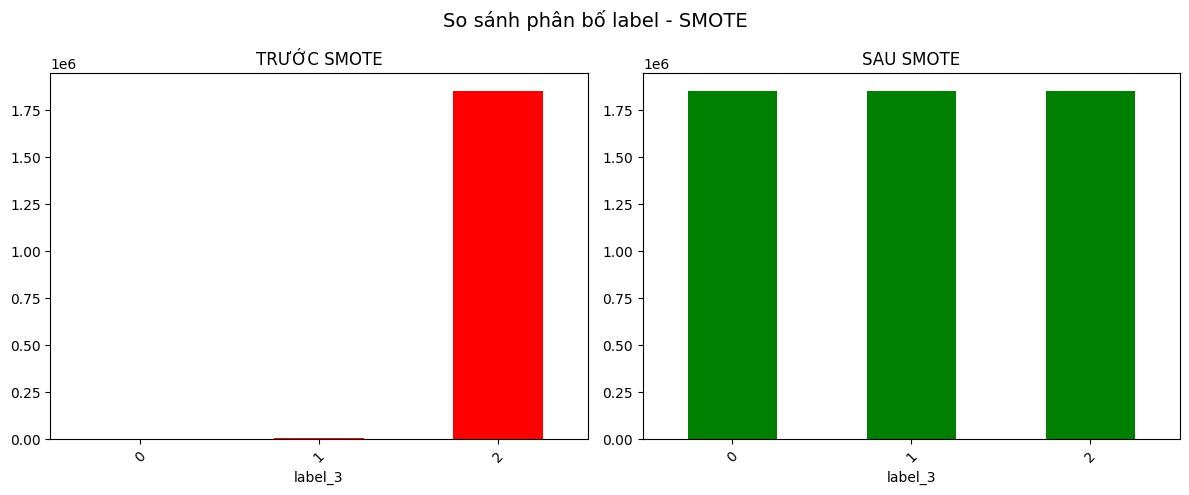

In [4]:
plt.figure(figsize=(12,5))

plt.subplot(1,2,1)
df_median[LABEL_COL].value_counts().sort_index().plot(kind='bar', title="TRƯỚC SMOTE", color='red')
plt.xticks(rotation=45)

plt.subplot(1,2,2)
df_balanced[LABEL_COL].value_counts().sort_index().plot(kind='bar', title="SAU SMOTE", color='green')
plt.xticks(rotation=45)

plt.suptitle("So sánh phân bố label - SMOTE", fontsize=14)
plt.tight_layout()
plt.show()

In [5]:
df_balanced.to_parquet("train_median_smote.parquet", index=False)

# Mean imputation

In [6]:
INPUT_FILE = "/kaggle/input/datasets/anhtran10/lo-dataset/Mean/Mean/train_mean.parquet"
LABEL_COL = "label_3"

df_mean = pd.read_parquet(INPUT_FILE)
print(f"Đã đọc file: {df_mean.shape}")
df_mean

Đã đọc file: (1859619, 182)


,user_id,course_id,course_duration,start_year,start_month,start_day,enrollment_to_end,label_3,gender,num_course_order,...,cmt_p4_max_comment_length_phase4,cmt_p4_text_diversity_phase4,cmt_p4_comment_days_active_phase4,cmt_p4_entropy_time_mean_phase4,cmt_p4_most_common_time_bin_phase4,cmt_p4_time_entropy_var_phase4,cmt_p4_positive_ratio_phase4,cmt_p4_neutral_ratio_phase4,cmt_p4_negative_ratio_phase4,cmt_p4_sentiment_entropy_phase4
0,418060,542,176,2020,2,6,170,2,2.0,6,...,37.895714,151.214508,1.305472,0.633849,29.86416,0.009356,0.241014,0.685691,0.073295,0.28781
1,140538,475,114,2020,10,30,76,2,0.0,58,...,37.895714,151.214508,1.305472,0.633849,29.86416,0.009356,0.241014,0.685691,0.073295,0.28781
2,125447,750,170,2020,2,12,69,2,0.0,56,...,37.895714,151.214508,1.305472,0.633849,29.86416,0.009356,0.241014,0.685691,0.073295,0.28781
3,24957,17,151,2020,2,16,138,2,2.0,7,...,37.895714,151.214508,1.305472,0.633849,29.86416,0.009356,0.241014,0.685691,0.073295,0.28781
4,977326,468,173,2020,10,30,140,2,2.0,2,...,37.895714,151.214508,1.305472,0.633849,29.86416,0.009356,0.241014,0.685691,0.073295,0.28781
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1859614,160452,856,91,2019,12,31,52,2,0.0,49,...,37.895714,151.214508,1.305472,0.633849,29.86416,0.009356,0.241014,0.685691,0.073295,0.28781
1859615,106770,862,121,2020,9,1,31,2,0.0,60,...,37.895714,151.214508,1.305472,0.633849,29.86416,0.009356,0.241014,0.685691,0.073295,0.28781
1859616,258729,833,93,2020,4,13,91,2,2.0,2,...,37.895714,151.214508,1.305472,0.633849,29.86416,0.009356,0.241014,0.685691,0.073295,0.28781
1859617,969906,616,121,2020,9,1,37,2,1.0,3,...,37.895714,151.214508,1.305472,0.633849,29.86416,0.009356,0.241014,0.685691,0.073295,0.28781


In [7]:
print(f"Phân bố label trước SMOTE:")
print(df_mean[LABEL_COL].value_counts().sort_index())

pure_smote = PureSMOTE(verbose=True, random_state=42)

df_balanced = pure_smote.fit_resample(df_mean, label_col="label_3")

print(f"\nPhân bố label sau SMOTE:")
print(df_balanced[LABEL_COL].value_counts().sort_index())

Phân bố label trước SMOTE:
label_3
0       1783
1       4839
2    1852997
Name: count, dtype: int64

SMOTE:

Class distribution BEFORE:
0       1783
1       4839
2    1852997
Name: count, dtype: int64

Class distribution AFTER:
label_3
0    1852997
1    1852997
2    1852997
Name: count, dtype: int64

Total samples: 5558991

Phân bố label sau SMOTE:
label_3
0    1852997
1    1852997
2    1852997
Name: count, dtype: int64


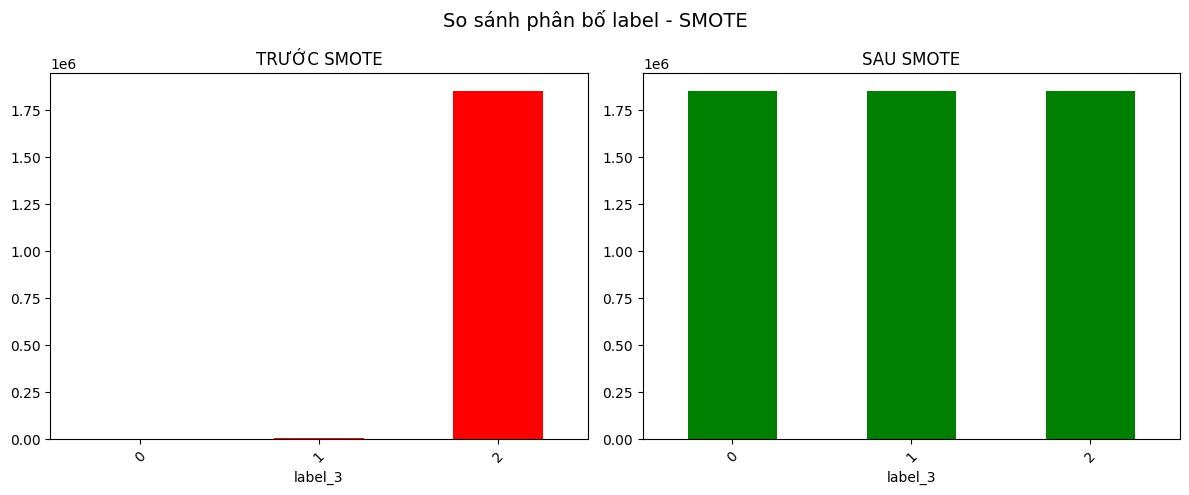

In [8]:
plt.figure(figsize=(12,5))

plt.subplot(1,2,1)
df_mean[LABEL_COL].value_counts().sort_index().plot(kind='bar', title="TRƯỚC SMOTE", color='red')
plt.xticks(rotation=45)

plt.subplot(1,2,2)
df_balanced[LABEL_COL].value_counts().sort_index().plot(kind='bar', title="SAU SMOTE", color='green')
plt.xticks(rotation=45)

plt.suptitle("So sánh phân bố label - SMOTE", fontsize=14)
plt.tight_layout()
plt.show()

In [9]:
df_balanced.to_parquet("train_mean_smote.parquet", index=False)

# Extra_trees imputation

In [10]:
INPUT_FILE = "/kaggle/input/datasets/anhtran10/lo-dataset/Extra_trees/Extra_trees/train_extra.parquet"
LABEL_COL = "label_3"

df_Extra_trees = pd.read_parquet(INPUT_FILE)
print(f"Đã đọc file: {df_Extra_trees.shape}")
df_Extra_trees

Đã đọc file: (1859619, 182)


,user_id,course_id,course_duration,start_year,start_month,start_day,enrollment_to_end,label_3,gender,num_course_order,...,cmt_p4_max_comment_length_phase4,cmt_p4_text_diversity_phase4,cmt_p4_comment_days_active_phase4,cmt_p4_entropy_time_mean_phase4,cmt_p4_most_common_time_bin_phase4,cmt_p4_time_entropy_var_phase4,cmt_p4_positive_ratio_phase4,cmt_p4_neutral_ratio_phase4,cmt_p4_negative_ratio_phase4,cmt_p4_sentiment_entropy_phase4
0,418060,542,176.0,2020.0,2.0,6.0,170.0,2,2.0,6.0,...,28.345097,75.224105,2.239722,0.651001,31.967399,0.010466,0.119216,0.749036,0.123232,0.743935
1,140538,475,114.0,2020.0,10.0,30.0,76.0,2,0.0,58.0,...,24.601815,77.347451,2.418864,0.657834,24.714212,0.006163,0.146233,0.768704,0.091260,0.712458
2,125447,750,170.0,2020.0,2.0,12.0,69.0,2,0.0,56.0,...,25.038668,67.816256,1.746079,0.684022,26.336268,0.004388,0.103833,0.770995,0.114709,0.704242
3,24957,17,151.0,2020.0,2.0,16.0,138.0,2,2.0,7.0,...,21.832723,61.084016,2.188559,0.651001,24.026333,0.007815,0.110005,0.761642,0.127080,0.719493
4,977326,468,173.0,2020.0,10.0,30.0,140.0,2,2.0,2.0,...,21.870573,68.990436,2.088095,0.657834,25.265029,0.003142,0.139406,0.761305,0.099424,0.738092
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1859614,160452,856,91.0,2019.0,12.0,31.0,52.0,2,0.0,49.0,...,48.100983,155.905533,2.164014,0.679425,25.602336,0.004796,0.163354,0.724069,0.105012,0.749764
1859615,106770,862,121.0,2020.0,9.0,1.0,31.0,2,0.0,60.0,...,40.613763,87.318300,2.086876,0.657834,31.689427,0.004874,0.097344,0.749513,0.159769,0.790002
1859616,258729,833,93.0,2020.0,4.0,13.0,91.0,2,2.0,2.0,...,21.292247,49.104277,1.740292,0.656641,27.509743,0.001563,0.099459,0.785990,0.114119,0.645251
1859617,969906,616,121.0,2020.0,9.0,1.0,37.0,2,1.0,3.0,...,36.010158,101.582165,1.676263,0.658539,25.701191,0.001337,0.098596,0.737834,0.163638,0.803611


In [11]:
print(f"Phân bố label trước SMOTE:")
print(df_Extra_trees[LABEL_COL].value_counts().sort_index())

pure_smote = PureSMOTE(verbose=True, random_state=42)

df_balanced = pure_smote.fit_resample(df_Extra_trees, label_col="label_3")

print(f"\nPhân bố label sau SMOTE:")
print(df_balanced[LABEL_COL].value_counts().sort_index())

Phân bố label trước SMOTE:
label_3
0       1783
1       4839
2    1852997
Name: count, dtype: int64

SMOTE:

Class distribution BEFORE:
0       1783
1       4839
2    1852997
Name: count, dtype: int64

Class distribution AFTER:
label_3
0    1852997
1    1852997
2    1852997
Name: count, dtype: int64

Total samples: 5558991

Phân bố label sau SMOTE:
label_3
0    1852997
1    1852997
2    1852997
Name: count, dtype: int64


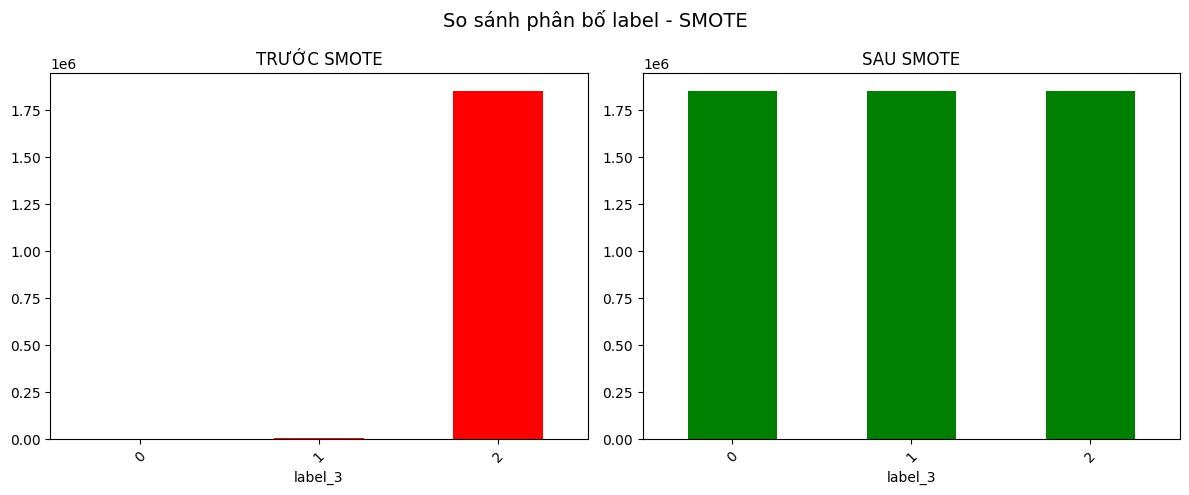

In [12]:
plt.figure(figsize=(12,5))

plt.subplot(1,2,1)
df_Extra_trees[LABEL_COL].value_counts().sort_index().plot(kind='bar', title="TRƯỚC SMOTE", color='red')
plt.xticks(rotation=45)

plt.subplot(1,2,2)
df_balanced[LABEL_COL].value_counts().sort_index().plot(kind='bar', title="SAU SMOTE", color='green')
plt.xticks(rotation=45)

plt.suptitle("So sánh phân bố label - SMOTE", fontsize=14)
plt.tight_layout()
plt.show()

In [13]:
df_balanced.to_parquet("train_extra_smote.parquet", index=False)